## Relevant Financial Metrics

- 52. [INC] Gross Profit
- 54. [INC] Total Revenue
- 55. [INC] Operating Revenue
- 150. [CAS] Free Cash Flow
[52, 54, 55, 150]


## Financial Statement Charter (Jupyter-compatible Script)

This script converts the original `tkinter` GUI application into a series of functions suitable for use in a Jupyter or Colab notebook. The GUI elements have been removed, and the data fetching and plotting capabilities are now exposed as callable functions.

### How to use:
1.  **Run the cells below** to define the necessary functions.
2.  **Define your desired tickers and period** (e.g., 'Annual' or 'Quarterly').
3.  **Call `fetch_financial_data`** to retrieve the financial statements.
4.  **Call `get_available_metrics`** to see which metrics are available for plotting.
5.  **Select the metrics** you wish to visualize.
6.  **Call `plot_financial_metrics`** to generate and display the charts.

In [16]:
# Imports and Global Constants
import math
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.ticker import FuncFormatter

import pandas as pd
import yfinance as yf

# Configure matplotlib for inline plotting in Jupyter/Colab
%matplotlib inline

MAX_COMPANIES = 7
MAX_METRICS = 7

# statement label -> (annual attribute, quarterly attribute) on yf.Ticker
STATEMENTS = {
    "Income Statement": ("income_stmt", "quarterly_income_stmt"),
    "Balance Sheet": ("balance_sheet", "quarterly_balance_sheet"),
    "Cash Flow": ("cashflow", "quarterly_cashflow"),
}

COLORS = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",
          "#9467bd", "#8c564b", "#e377c2"]


In [17]:
def human_fmt(x, _pos=None):
    """Format large dollar values: 1.5B, 320M, 45K."""
    if x is None or (isinstance(x, float) and math.isnan(x)):
        return ""
    sign = "-" if x < 0 else ""
    x = abs(x)
    for div, suffix in ((1e12, "T"), (1e9, "B"), (1e6, "M"), (1e3, "K")):
        if x >= div:
            return f"{sign}{x / div:.1f}{suffix}"
    return f"{sign}{x:.0f}"


In [18]:
def fetch_financial_data(ticker_symbols, period_type):
    """
    Fetches financial data for a list of ticker symbols and a specified period.

    Args:
        ticker_symbols (list): A list of ticker symbols (e.g., ['UBER', 'LYFT']).
        period_type (str): 'Annual' or 'Quarterly'.

    Returns:
        tuple: A tuple containing:
            - dict: A dictionary where keys are ticker symbols and values are
                    dictionaries containing 'Annual'/'Quarterly' dataframes
                    for 'Income Statement', 'Balance Sheet', and 'Cash Flow'.
            - list: A list of error messages encountered during fetching.
    """
    data = {}
    errors = []

    if not ticker_symbols:
        errors.append("No ticker symbols provided.")
        return data, errors
    if len(ticker_symbols) > MAX_COMPANIES:
        errors.append(f"Please provide at most {MAX_COMPANIES} tickers.")
        return data, errors

    print(f"Fetching {period_type} data for {', '.join(ticker_symbols)}...")

    for t in ticker_symbols:
        try:
            tk_obj = yf.Ticker(t)
            per_ticker = {"Annual": {}, "Quarterly": {}}
            for label, (annual_attr, quarterly_attr) in STATEMENTS.items():
                per_ticker["Annual"][label] = getattr(tk_obj, annual_attr)
                per_ticker["Quarterly"][label] = getattr(tk_obj, quarterly_attr)

            # Sanity check: at least one non-empty statement for the selected period
            selected_period_data = per_ticker[period_type]
            if all(df is None or df.empty for df in selected_period_data.values()):
                errors.append(f"{t}: no {period_type.lower()} financial data returned")
            else:
                data[t] = per_ticker
        except Exception as exc:  # network errors, bad symbols, etc.
            errors.append(f"{t}: {exc}")

    if not data:
        print("No data loaded.")
    else:
        print(f"Successfully loaded data for: {', '.join(data.keys())}")

    if errors:
        print("Issues encountered:")
        for err in errors:
            print(f"- {err}")

    return data, errors


In [19]:
def calculate_profit_margin(fetched_data, period_type):
    """
    Calculates 'Profit Margin' (Gross Profit / Total Revenue) for each company and adds
    it to the fetched_data structure under the 'Income Statement' category.

    Args:
        fetched_data (dict): The data dictionary returned by `fetch_financial_data`.
        period_type (str): 'Annual' or 'Quarterly'.

    Returns:
        dict: The updated fetched_data dictionary with 'Profit Margin' added.
    """
    updated_data = fetched_data.copy()
    for ticker, ticker_data in updated_data.items():
        # Ensure 'Income Statement' DataFrame exists for the current period_type,
        # creating an empty one if not present or None.
        if 'Income Statement' not in ticker_data[period_type] or ticker_data[period_type]['Income Statement'] is None:
            ticker_data[period_type]['Income Statement'] = pd.DataFrame(dtype=float) # Create an empty DataFrame

        income_stmt_df = ticker_data[period_type]['Income Statement']

        # Get GrossProfit and TotalRevenue series, handling cases where they might be missing
        # Use existing columns as index for empty series to ensure alignment with dates
        gross_profit = income_stmt_df.loc['Gross Profit'] if 'Gross Profit' in income_stmt_df.index else pd.Series(dtype=float, index=income_stmt_df.columns)
        total_revenue = income_stmt_df.loc['Total Revenue'] if 'Total Revenue' in income_stmt_df.index else pd.Series(dtype=float, index=income_stmt_df.columns)

        # Create a combined index from all available dates for gross_profit and total_revenue,
        # or from the income_stmt_df columns if both are empty. This ensures proper alignment.
        combined_index = income_stmt_df.columns # Start with existing dates
        if not gross_profit.empty:
            combined_index = combined_index.union(gross_profit.index)
        if not total_revenue.empty:
            combined_index = combined_index.union(total_revenue.index)

        # Reindex series to cover all relevant dates, filling missing dates with NaN
        gross_profit_reindexed = gross_profit.reindex(combined_index)
        total_revenue_reindexed = total_revenue.reindex(combined_index)

        # Perform the division, resulting in NaN where data is missing for either part
        # Multiply by 100 to express as a percentage
        profit_margin = (gross_profit_reindexed / total_revenue_reindexed) * 100
        profit_margin = profit_margin.rename('Profit Margin')

        # Ensure income_stmt_df has all necessary columns (dates) before assigning/concatenating
        # This handles cases where the original income_stmt_df was empty but we now have dates.
        income_stmt_df = income_stmt_df.reindex(columns=combined_index, fill_value=float('nan'))

        # Add 'Profit Margin' to the Income Statement DataFrame
        income_stmt_df.loc['Profit Margin'] = profit_margin

        ticker_data[period_type]['Income Statement'] = income_stmt_df

    print(f"'Profit Margin' calculated and added to the {period_type} Income Statements.")
    return updated_data

In [20]:
def get_available_metrics(fetched_data, period_type):
    """
    Generates a list of all unique financial metrics available across all fetched companies
    for a given period type.

    Args:
        fetched_data (dict): The data dictionary returned by `fetch_financial_data`.
        period_type (str): 'Annual' or 'Quarterly'.

    Returns:
        list: A list of (statement_label, metric_name) tuples representing available metrics.
    """
    metric_index = []
    for label in STATEMENTS:
        seen = set()
        for t in fetched_data:
            df = fetched_data[t][period_type].get(label)
            if df is None or df.empty:
                continue
            for metric in df.index:
                if metric not in seen:
                    seen.add(metric)
                    metric_index.append((label, metric))
    return metric_index


In [21]:
def plot_financial_metrics(fetched_data, selected_metrics, period_type, ticker_symbols):
    """
    Plots the selected financial metrics for the specified companies and period type.

    Args:
        fetched_data (dict): The data dictionary returned by `fetch_financial_data`.
        selected_metrics (list): A list of (statement_label, metric_name) tuples to plot.
        period_type (str): 'Annual' or 'Quarterly'.
        ticker_symbols (list): The original list of ticker symbols that were fetched.
    """
    if not selected_metrics:
        print("No metrics selected to plot.")
        return
    if len(selected_metrics) > MAX_METRICS:
        print(f"Please select at most {MAX_METRICS} metrics to plot.")
        return

    n = len(selected_metrics)
    ncols = 1 if n == 1 else (2 if n > 1 else 1) # Adjust columns for better layout
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows, ncols, figsize=(10 * ncols, 6 * nrows))
    # Ensure axes is always iterable, even for a single subplot
    axes = axes.flatten() if n > 1 else [axes]

    color_map = {t: COLORS[i % len(COLORS)] for i, t in enumerate(ticker_symbols)}
    plotted_tickers = set()

    for i, (stmt_label, metric) in enumerate(selected_metrics):
        ax = axes[i]
        for t in ticker_symbols:
            df = fetched_data.get(t, {}).get(period_type, {}).get(stmt_label)
            if df is None or df.empty or metric not in df.index:
                continue
            series = df.loc[metric].dropna()
            if series.empty:
                continue
            series = series.sort_index()
            x = pd.to_datetime(series.index)
            ax.plot(x, series.values, marker="o", linewidth=1.8,
                    color=color_map[t], label=t)
            plotted_tickers.add(t)

        ax.set_title(f"{metric}\n({stmt_label}, {period_type})", fontsize=10)
        ax.yaxis.set_major_formatter(FuncFormatter(human_fmt))
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)

    # Hide any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # One shared legend for the whole figure
    handles = [plt.Line2D([], [], color=color_map[t], marker="o",
                          linewidth=1.8, label=t)
               for t in sorted(list(plotted_tickers))]
    if handles:
        fig.legend(handles=handles, loc="upper center",
                   ncol=min(len(handles), 7), fontsize=10, frameon=False, bbox_to_anchor=(0.5, 1.02))

    fig.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make space for legend
    plt.show()


In [22]:
def export_financial_metrics_to_csv(fetched_data, selected_metrics, period_type, ticker_symbols, filename="financial_metrics.csv"):
    """
    Exports the selected financial metrics data for the specified companies to a CSV file.

    Args:
        fetched_data (dict): The data dictionary returned by `fetch_financial_data`.
        selected_metrics (list): A list of (statement_label, metric_name) tuples to export.
        period_type (str): 'Annual' or 'Quarterly'.
        ticker_symbols (list): The original list of ticker symbols that were fetched.
        filename (str): The name of the CSV file to save the data to.
    """
    if not selected_metrics:
        print("No metrics selected to export.")
        return

    all_data_to_export = []

    for stmt_label, metric in selected_metrics:
        for t in ticker_symbols:
            df = fetched_data.get(t, {}).get(period_type, {}).get(stmt_label)
            if df is None or df.empty or metric not in df.index:
                continue
            series = df.loc[metric].dropna()
            if series.empty:
                continue

            # Create a DataFrame for this series and add metadata
            metric_df = series.reset_index()
            metric_df.columns = ['Date', 'Value']
            metric_df['Ticker'] = t
            metric_df['Statement'] = stmt_label
            metric_df['Metric'] = metric
            all_data_to_export.append(metric_df)

    if all_data_to_export:
        combined_df = pd.concat(all_data_to_export, ignore_index=True)
        combined_df['Date'] = pd.to_datetime(combined_df['Date']).dt.date # Keep only date part
        combined_df.to_csv(filename, index=False)
        print(f"Data successfully exported to {filename}")
    else:
        print("No data found for the selected metrics and tickers to export.")


### Example Usage

Fetching Annual data for AAPL, GOOG, COST, MSFT, TADAWUL: 2222...
Successfully loaded data for: AAPL, GOOG, COST, MSFT
Issues encountered:
- TADAWUL: 2222: no annual financial data returned
'Profit Margin' calculated and added to the Annual Income Statements.

Available Metrics (Statement, Metric Name):
1. [INC] Tax Effect Of Unusual Items
2. [INC] Tax Rate For Calcs
3. [INC] Normalized EBITDA
4. [INC] Net Income From Continuing Operation Net Minority Interest
5. [INC] Reconciled Depreciation
6. [INC] Reconciled Cost Of Revenue
7. [INC] EBITDA
8. [INC] EBIT
9. [INC] Net Interest Income
10. [INC] Interest Expense
11. [INC] Interest Income
12. [INC] Normalized Income
13. [INC] Net Income From Continuing And Discontinued Operation
14. [INC] Total Expenses
15. [INC] Total Operating Income As Reported
16. [INC] Diluted Average Shares
17. [INC] Basic Average Shares
18. [INC] Diluted EPS
19. [INC] Basic EPS
20. [INC] Diluted NI Availto Com Stockholders
21. [INC] Net Income Common Stockholders

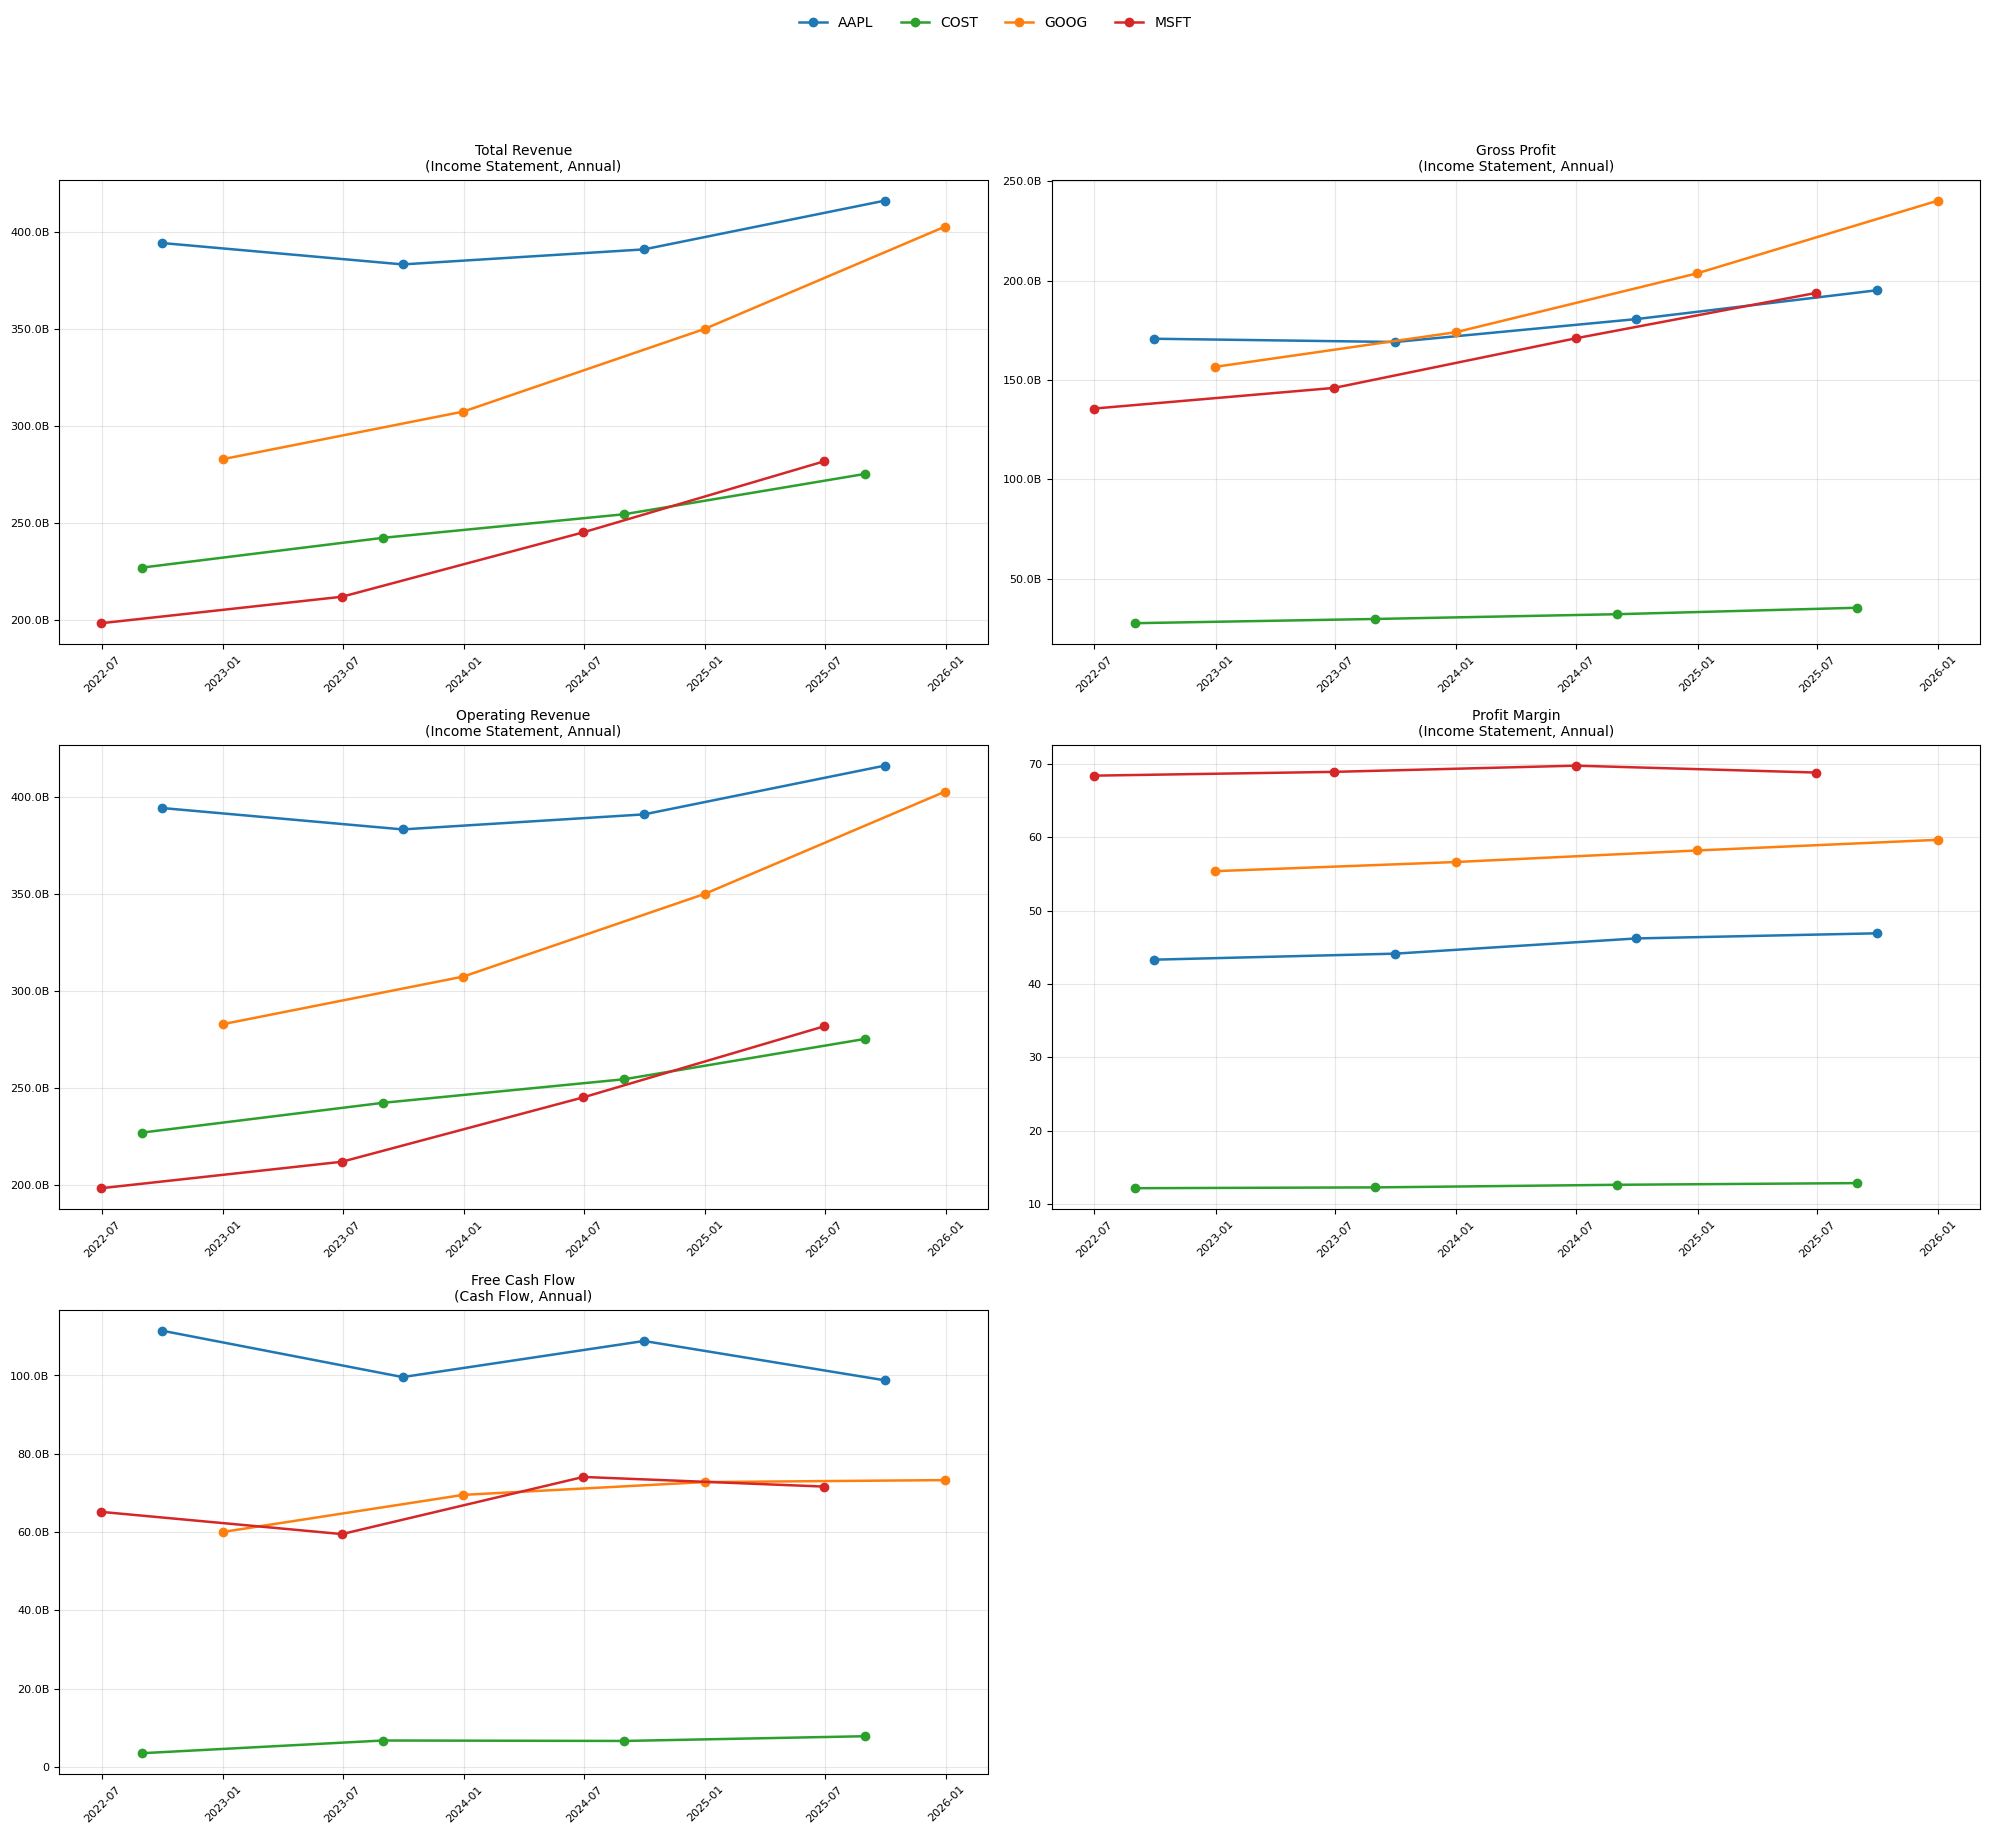

In [23]:
# 1. Define your tickers and period
my_tickers = ['AAPL', 'GOOG', 'COST', 'MSFT', 'TADAWUL: 2222'] # You can change these
my_period = 'Annual' # Or 'Quarterly'

# 2. Fetch the financial data
financial_data, fetch_errors = fetch_financial_data(my_tickers, my_period)

# 2a. Calculate additional metrics like Profit Margin
if financial_data:
    financial_data = calculate_profit_margin(financial_data, my_period)

# 3. Get available metrics from the fetched data (now including calculated ones)
if financial_data:
    available_metrics = get_available_metrics(financial_data, my_period)
    print("\nAvailable Metrics (Statement, Metric Name):")
    for i, (stmt, metric) in enumerate(available_metrics):
        print(f"{i+1}. [{stmt[:3].upper()}] {metric}")

    # 4. Select metrics to plot by explicit (Statement, Metric Name) tuples
    # This is more robust than using indices.
    desired_metrics_to_plot = [
        ('Income Statement', 'Total Revenue'),
        ('Income Statement', 'Gross Profit'), # Corrected to include space
        ('Income Statement', 'Operating Revenue'),
        ('Income Statement', 'Profit Margin'), # Explicitly add Profit Margin
        ('Cash Flow', 'Free Cash Flow') # Example for another statement
    ]

    selected_metrics = []
    for desired_metric_tuple in desired_metrics_to_plot:
        if desired_metric_tuple in available_metrics:
            selected_metrics.append(desired_metric_tuple)
        else:
            print(f"Warning: Desired metric {desired_metric_tuple} not found in available metrics and will not be plotted.")

    print(f"\nSelected Metrics for plotting: {selected_metrics}")

    # 5. Plot the selected metrics
    plot_financial_metrics(financial_data, selected_metrics, my_period, my_tickers)
else:
    print("Cannot proceed to plot as no data was successfully loaded.")

In [24]:
# 6. Export the selected metrics data to a CSV file
if financial_data:
    export_filename = 'selected_financial_metrics.csv'
    export_financial_metrics_to_csv(financial_data, selected_metrics, my_period, my_tickers, export_filename)


Data successfully exported to selected_financial_metrics.csv


## Resources